In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import pandasql as ps 
import matplotlib.pyplot as plt
import re
import plotly.graph_objs as go
from matplotlib import colors 
from wordcloud import WordCloud
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
%matplotlib inline

In [2]:
df = pd.read_csv("../input/mobile-price-classification/train.csv") 
df.head(15)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
print(df.isnull().any())

battery_power    False
blue             False
clock_speed      False
dual_sim         False
fc               False
four_g           False
int_memory       False
m_dep            False
mobile_wt        False
n_cores          False
pc               False
px_height        False
px_width         False
ram              False
sc_h             False
sc_w             False
talk_time        False
three_g          False
touch_screen     False
wifi             False
price_range      False
dtype: bool


In [5]:
df.shape

(2000, 21)

In [6]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

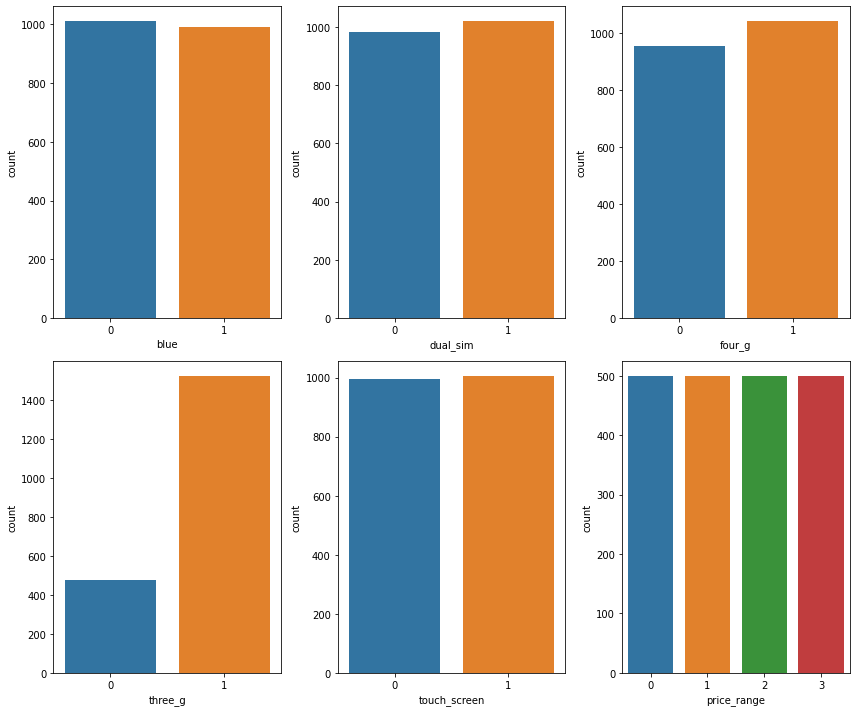

In [7]:
plt.figure(figsize=(12,10))
col = ['blue','dual_sim','four_g','three_g','touch_screen','price_range']
c = 1
for i in col:
    if c < 7:
        plt.subplot(2,3,c)
        sns.countplot(x = i,data =df)
        plt.xlabel(i)
    c += 1
    plt.tight_layout()

<Figure size 864x720 with 0 Axes>

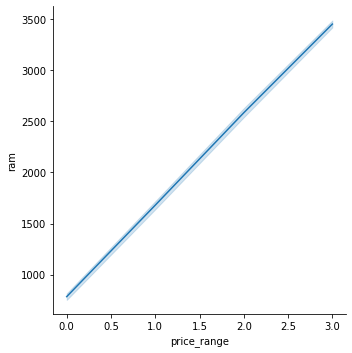

In [8]:
plt.figure(figsize=(12,10))
sns.relplot(x = 'price_range',y = 'ram',data = df,kind = 'line')

In [9]:
df['price_range'].value_counts() # Number of Unique value of price_range columns.

1    500
2    500
3    500
0    500
Name: price_range, dtype: int64

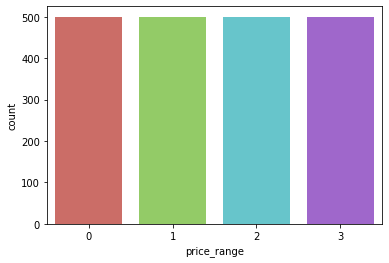

In [10]:
sns.countplot(x = 'price_range',data=df,palette = 'hls')
plt.show()

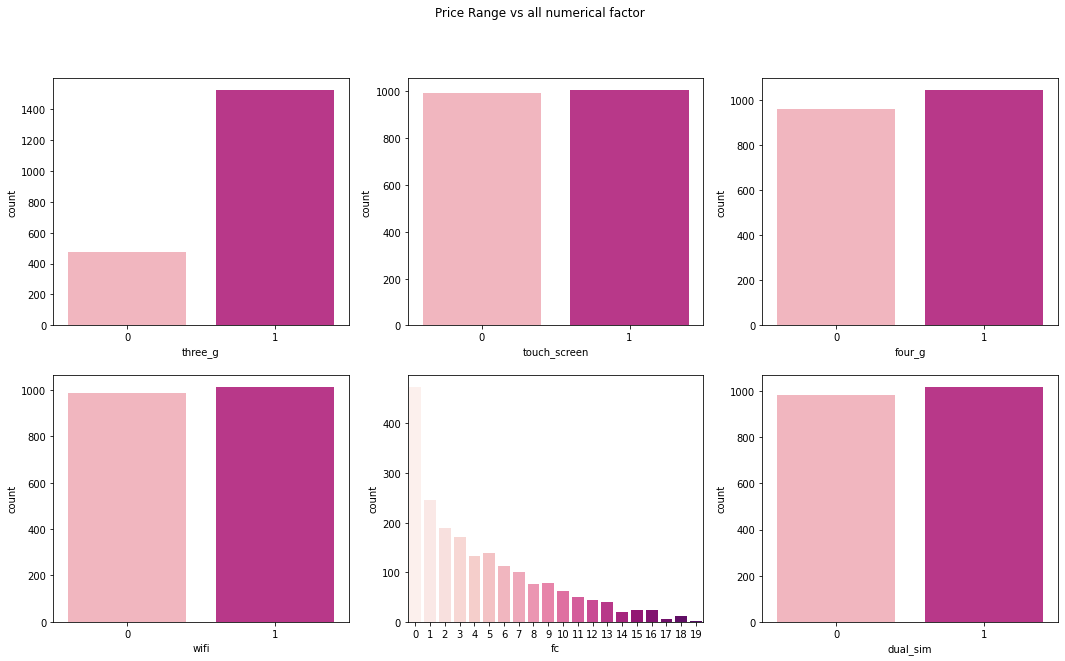

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Price Range vs all numerical factor')
sns.countplot(ax=axes[0, 0], data=df, x='three_g',palette='RdPu')
sns.countplot(ax=axes[0, 1], data=df, x='touch_screen',palette='RdPu')
sns.countplot(ax=axes[0, 2], data=df, x='four_g',palette='RdPu')
sns.countplot(ax=axes[1, 0], data=df, x='wifi',palette='RdPu')
sns.countplot(ax=axes[1,1],data = df, x ='fc' ,palette='RdPu')
sns.countplot(ax=axes[1,2],data = df, x ='dual_sim',palette='RdPu' )
plt.show()

<AxesSubplot:>

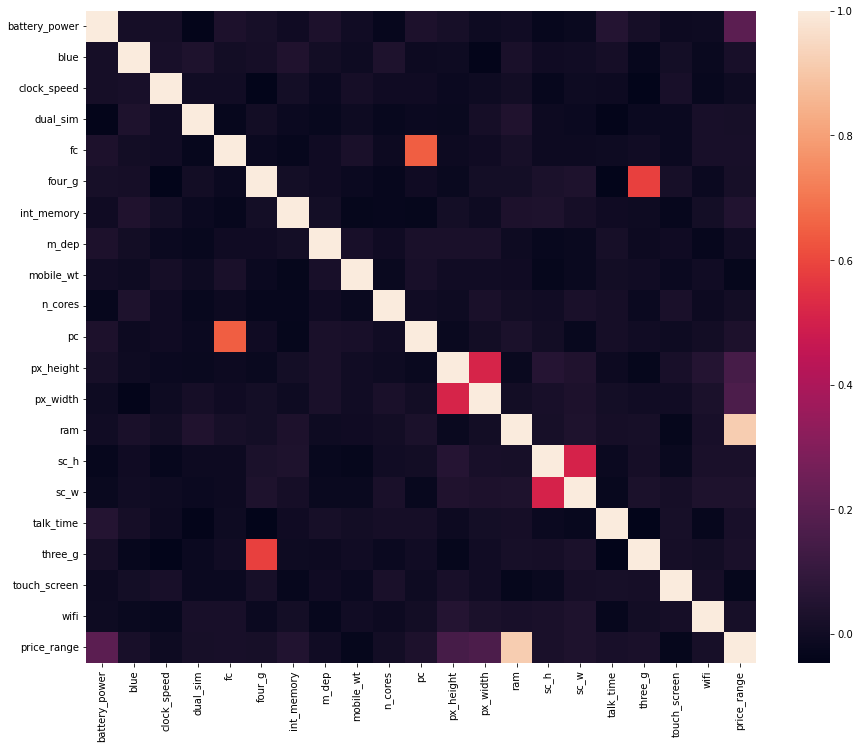

In [12]:
fig = plt.figure(figsize=(15,12))
sns.heatmap(df.corr())

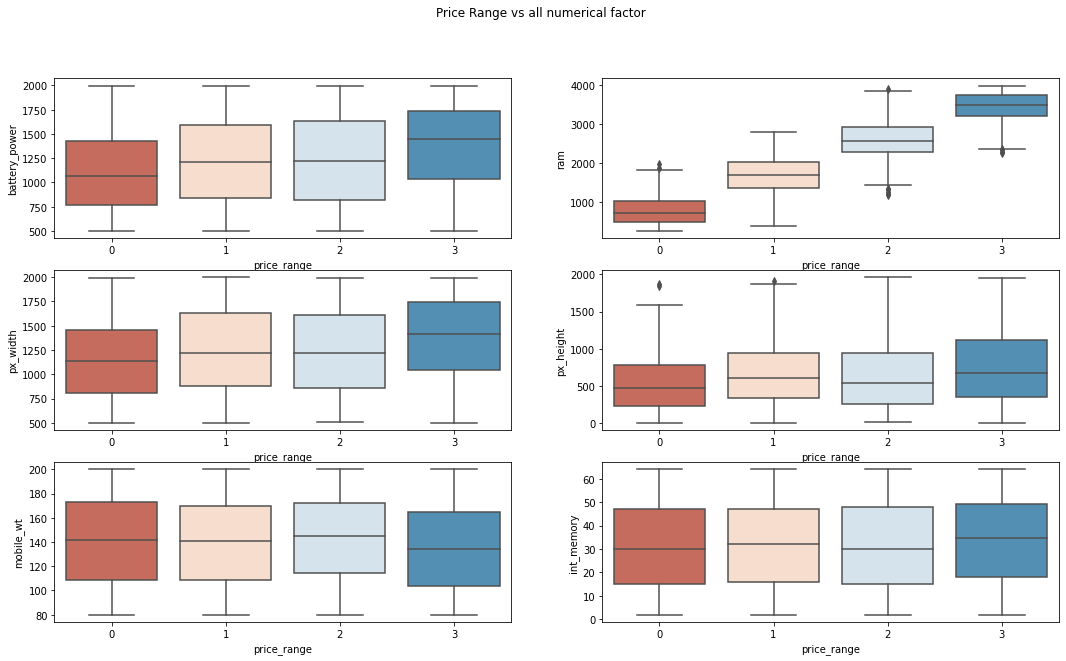

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))

fig.suptitle('Price Range vs all numerical factor')

sns.boxplot(ax=axes[0, 0], data=df, x='price_range', y='battery_power',palette = "RdBu")
sns.boxplot(ax=axes[0, 1], data=df, x='price_range', y='ram',palette = "RdBu")
sns.boxplot(ax=axes[1, 0], data=df, x='price_range', y='px_width',palette = "RdBu")
sns.boxplot(ax=axes[1, 1], data=df, x='price_range', y='px_height',palette = "RdBu")
sns.boxplot(ax=axes[2,0],data=df,x='price_range',y='mobile_wt',palette = "RdBu")
sns.boxplot(ax=axes[2,1],data=df,x='price_range',y='int_memory',palette = "RdBu")
plt.show()

In [14]:
X = df.drop('price_range',axis=1)
y = df['price_range']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.33,random_state=42)

**1. Linear Regression**

In [16]:
lrm = LinearRegression()
lrm.fit(X_train,y_train)
lrm.score(X_test,y_test)

0.9190369530612715

**2. Logistic Regression**

In [17]:

lr = LogisticRegression()
lr.fit(X_train,y_train)

#getting confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = lr.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix:\n',cm)

#checking accuracy
from sklearn.metrics import accuracy_score
lra = accuracy_score(y_test,y_pred)
print('accuracy score = ',lra)

confusion matrix:
 [[131  37   1   0]
 [ 33  82  36  11]
 [  1  34  85  42]
 [  0   3  41 123]]
accuracy score =  0.6378787878787879


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


**3. SVM**

In [18]:
classifier = SVC(kernel = 'linear', random_state = 0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [19]:
y_pred = classifier.predict(X_test)

In [20]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
acc2 = accuracy_score(y_test, y_pred)

[[164   5   0   0]
 [  1 160   1   0]
 [  0   3 154   5]
 [  0   0   1 166]]


In [21]:
print(f"Accuracy score: {acc2}")

Accuracy score: 0.9757575757575757


**4. KNN**

In [22]:
knn = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski',p = 2)
knn.fit(X_train,y_train)

#getting confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix:\n',cm)

#checking accuracy
from sklearn.metrics import accuracy_score
knna = accuracy_score(y_test,y_pred)
print('accuracy score = ',accuracy_score(y_test,y_pred))

confusion matrix:
 [[163   6   0   0]
 [  5 149   8   0]
 [  0  12 140  10]
 [  0   0  11 156]]
accuracy score =  0.9212121212121213


**5. NB**

In [23]:
nb = GaussianNB()
nb.fit(X_train,y_train)

#getting confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = nb.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix:\n',cm)

#checking accuracy
from sklearn.metrics import accuracy_score
nba = accuracy_score(y_test,y_pred)
print('accuracy score = ',accuracy_score(y_test,y_pred))

confusion matrix:
 [[154  15   0   0]
 [ 14 119  29   0]
 [  0  28 117  17]
 [  0   0  26 141]]
accuracy score =  0.8045454545454546


**6. DT**

In [24]:
#Decision Tree


dt = DecisionTreeClassifier(criterion = 'entropy')
dt.fit(X_train,y_train)

#getting confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
print('confusion matrix:\n',cm)

#checking accuracy
from sklearn.metrics import accuracy_score
dta = accuracy_score(y_test,y_pred)
print('accuracy score = ',accuracy_score(y_test,y_pred))

confusion matrix:
 [[142  27   0   0]
 [ 11 136  15   0]
 [  0  24 117  21]
 [  0   0  19 148]]
accuracy score =  0.8227272727272728


# Comparing Models

In [25]:
df = pd.DataFrame({'models' : ['Logistic Regression','Linear Regression','svm','knna','Naive Bayes','Decision Tree'], 'Accuracy Score':['64','92','98','92','80','82']})

In [26]:
df.sort_values(by = 'Accuracy Score', ascending = False)

,models,Accuracy Score
2,svm,98
1,Linear Regression,92
3,knna,92
5,Decision Tree,82
4,Naive Bayes,80
0,Logistic Regression,64
